In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('D:\Machine Learning\Smart-Irrigation-Project\Data\Raw\Smart_Agriculture.csv')
df.head()

,Farm_ID,Region,Crop_Type,Soil_Type,Growth_Stage,Irrigation_Type,Temperature,Humidity,Rainfall,Forecast_Rainfall,...,Previous_Yield,Groundwater_Level,Reservoir_Level,Fertilizer_Usage,Labor_Hours,Water_Quantity_Required_Liters,Future_Soil_Moisture_3Day,Crop_Water_Stress_Level,Irrigation_Required,Yield_Prediction
0,1,East,Cotton,Loamy,Vegetative,Drip,30.11,56.83,244.37,25.49,...,1.03,16.77,23.39,290.85,16.62,73.29,8.14,High,No,3.82
1,2,West,Cotton,Silty,Seedling,Sprinkler,16.98,33.83,77.67,7.17,...,1.41,33.45,23.30,139.65,15.81,19.40,56.59,Low,No,4.83
2,3,North,Sugarcane,Clay,Seedling,Sprinkler,41.51,56.24,241.26,38.82,...,4.62,24.75,81.55,221.48,19.07,41.65,29.49,Medium,No,3.80
3,4,East,Cotton,Clay,Vegetative,Drip,37.59,34.14,124.00,73.21,...,5.98,30.36,71.38,205.37,3.84,34.29,61.27,Low,No,6.23
4,5,East,Maize,Sandy,Seedling,Drip,26.36,72.79,79.94,21.39,...,4.18,19.04,60.92,159.94,19.99,23.95,41.61,Low,No,2.87


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 41 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Farm_ID                         10000 non-null  int64  
 1   Region                          10000 non-null  object 
 2   Crop_Type                       10000 non-null  object 
 3   Soil_Type                       10000 non-null  object 
 4   Growth_Stage                    10000 non-null  object 
 5   Irrigation_Type                 10000 non-null  object 
 6   Temperature                     10000 non-null  float64
 7   Humidity                        10000 non-null  float64
 8   Rainfall                        10000 non-null  float64
 9   Forecast_Rainfall               10000 non-null  float64
 10  Wind_Speed                      10000 non-null  float64
 11  Solar_Radiation                 10000 non-null  float64
 12  Pressure                        1

In [6]:
df.columns = df.columns.str.strip().str.lower()
df.columns

Index(['farm_id', 'region', 'crop_type', 'soil_type', 'growth_stage',
       'irrigation_type', 'temperature', 'humidity', 'rainfall',
       'forecast_rainfall', 'wind_speed', 'solar_radiation', 'pressure',
       'cloud_cover', 'dew_point', 'soil_moisture', 'soil_temperature',
       'soil_ph', 'nitrogen', 'phosphorus', 'potassium', 'organic_matter',
       'ec', 'leaf_wetness', 'evapotranspiration', 'ndvi', 'crop_age_days',
       'water_usage', 'pest_risk', 'disease_risk', 'crop_health_index',
       'previous_yield', 'groundwater_level', 'reservoir_level',
       'fertilizer_usage', 'labor_hours', 'water_quantity_required_liters',
       'future_soil_moisture_3day', 'crop_water_stress_level',
       'irrigation_required', 'yield_prediction'],
      dtype='object')

# **Remove Unnecessary Column**

In [7]:
df = df.drop('farm_id',axis=1)

In [8]:
df.columns

Index(['region', 'crop_type', 'soil_type', 'growth_stage', 'irrigation_type',
       'temperature', 'humidity', 'rainfall', 'forecast_rainfall',
       'wind_speed', 'solar_radiation', 'pressure', 'cloud_cover', 'dew_point',
       'soil_moisture', 'soil_temperature', 'soil_ph', 'nitrogen',
       'phosphorus', 'potassium', 'organic_matter', 'ec', 'leaf_wetness',
       'evapotranspiration', 'ndvi', 'crop_age_days', 'water_usage',
       'pest_risk', 'disease_risk', 'crop_health_index', 'previous_yield',
       'groundwater_level', 'reservoir_level', 'fertilizer_usage',
       'labor_hours', 'water_quantity_required_liters',
       'future_soil_moisture_3day', 'crop_water_stress_level',
       'irrigation_required', 'yield_prediction'],
      dtype='object')

# **Handle Categorical Features**

In [9]:
cat_features= df.select_dtypes(include=['object']).columns
print("Categorical Features:",cat_features)

Categorical Features: Index(['region', 'crop_type', 'soil_type', 'growth_stage', 'irrigation_type',
       'crop_water_stress_level', 'irrigation_required'],
      dtype='object')


In [10]:
#check region feature unique values
df['region'].unique()

array(['East', 'West', 'North', 'South'], dtype=object)

In [11]:
df['crop_type'] = df['crop_type'].astype('object')
df['crop_type']

0          Cotton
1          Cotton
2       Sugarcane
3          Cotton
4           Maize
          ...    
9995    Sugarcane
9996    Sugarcane
9997        Wheat
9998        Wheat
9999        Wheat
Name: crop_type, Length: 10000, dtype: object

In [12]:
df['crop_type'].unique()

array(['Cotton', 'Sugarcane', 'Maize', 'Wheat', 'Rice'], dtype=object)

In [13]:
#check soil_type feature unique values
df['soil_type'].unique()

array(['Loamy', 'Silty', 'Clay', 'Sandy'], dtype=object)

In [14]:
#check growth_stage feature unique values
df['growth_stage'].unique()

array(['Vegetative', 'Seedling', 'Flowering', 'Maturity'], dtype=object)

In [15]:
#check irrigation_type feature unique values
df['irrigation_type'].unique()

array(['Drip', 'Sprinkler', 'Flood'], dtype=object)

In [16]:
#check crop_water_stress_level feature unique values
df['crop_water_stress_level'].unique()

array(['High', 'Low', 'Medium'], dtype=object)

In [17]:
#check irrigation_required feature unique values
df['irrigation_required'].unique()

array(['No', 'Yes'], dtype=object)

In [18]:
results = pd.DataFrame({
    'column': [
         'crop_type',
         'region',
         'irrigation_required',
         'irrigation_type',
         'growth_stage',
         'crop_water_stress_level',
         'soil_type'
    ],
    'Unique values count': [
        df['crop_type'].nunique(),
        df['region'].nunique(),
        df['irrigation_required'].nunique(),
        df['irrigation_type'].nunique(),
        df['growth_stage'].nunique(),
        df['crop_water_stress_level'].nunique(),
        df['soil_type'].nunique()
    ],
    'Encoding Method': [
        'One-Hot Encoding',
        'One-Hot Encoding',
        'Label Encoding',
        'One-Hot Encoding',
        'Label Encoding',
        'Label Encoding',
        'One-Hot Encoding'
    ]})

In [19]:
results

,column,Unique values count,Encoding Method
0,crop_type,5,One-Hot Encoding
1,region,4,One-Hot Encoding
2,irrigation_required,2,Label Encoding
3,irrigation_type,3,One-Hot Encoding
4,growth_stage,4,Label Encoding
5,crop_water_stress_level,3,Label Encoding
6,soil_type,4,One-Hot Encoding


# **Outlier Analysis**

In [20]:
#select only numerical features
num_col = df.select_dtypes(include=['int64','float64']).columns
print("Numerical Features:",num_col)

num_col_list = num_col.tolist()
num_col_list

Numerical Features: Index(['temperature', 'humidity', 'rainfall', 'forecast_rainfall',
       'wind_speed', 'solar_radiation', 'pressure', 'cloud_cover', 'dew_point',
       'soil_moisture', 'soil_temperature', 'soil_ph', 'nitrogen',
       'phosphorus', 'potassium', 'organic_matter', 'ec', 'leaf_wetness',
       'evapotranspiration', 'ndvi', 'crop_age_days', 'water_usage',
       'pest_risk', 'disease_risk', 'crop_health_index', 'previous_yield',
       'groundwater_level', 'reservoir_level', 'fertilizer_usage',
       'labor_hours', 'water_quantity_required_liters',
       'future_soil_moisture_3day', 'yield_prediction'],
      dtype='object')


['temperature',
 'humidity',
 'rainfall',
 'forecast_rainfall',
 'wind_speed',
 'solar_radiation',
 'pressure',
 'cloud_cover',
 'dew_point',
 'soil_moisture',
 'soil_temperature',
 'soil_ph',
 'nitrogen',
 'phosphorus',
 'potassium',
 'organic_matter',
 'ec',
 'leaf_wetness',
 'evapotranspiration',
 'ndvi',
 'crop_age_days',
 'water_usage',
 'pest_risk',
 'disease_risk',
 'crop_health_index',
 'previous_yield',
 'groundwater_level',
 'reservoir_level',
 'fertilizer_usage',
 'labor_hours',
 'water_quantity_required_liters',
 'future_soil_moisture_3day',
 'yield_prediction']

In [21]:
remove_features=[
            'crop_type',
            'region',
            'irrigation_required',
            'irrigation_type',
            'growth_stage',
            'crop_water_stress_level',
            'soil_type'
    ]

for item in remove_features:
    try:
        idx = num_col_list.index(item)   # find position
        num_col_list.pop(idx)            # remove by index
    except ValueError:
        # item not in list — ignore
        pass

print("Filtered numerical features:", num_col_list)

Filtered numerical features: ['temperature', 'humidity', 'rainfall', 'forecast_rainfall', 'wind_speed', 'solar_radiation', 'pressure', 'cloud_cover', 'dew_point', 'soil_moisture', 'soil_temperature', 'soil_ph', 'nitrogen', 'phosphorus', 'potassium', 'organic_matter', 'ec', 'leaf_wetness', 'evapotranspiration', 'ndvi', 'crop_age_days', 'water_usage', 'pest_risk', 'disease_risk', 'crop_health_index', 'previous_yield', 'groundwater_level', 'reservoir_level', 'fertilizer_usage', 'labor_hours', 'water_quantity_required_liters', 'future_soil_moisture_3day', 'yield_prediction']


In [22]:
df[num_col_list].describe().T

,count,mean,std,min,25%,50%,75%,max
temperature,10000.0,29.978526,8.661454,15.00,22.4300,30.040,37.4325,44.99
humidity,10000.0,57.259388,21.737936,20.00,38.2600,56.910,76.4225,95.00
rainfall,10000.0,151.030532,86.390499,0.00,77.2075,152.285,225.6425,299.98
forecast_rainfall,10000.0,50.064710,28.774127,0.03,25.3300,50.160,75.2100,99.97
wind_speed,10000.0,14.978688,8.579118,0.00,7.5500,14.980,22.4400,30.00
solar_radiation,10000.0,551.289992,261.826972,100.12,321.5575,554.450,783.0400,999.99
pressure,10000.0,999.603721,28.868393,950.00,974.4400,999.860,1024.3425,1050.00
cloud_cover,10000.0,49.889211,28.813966,0.01,24.5550,50.030,74.8125,99.98
dew_point,10000.0,15.087630,8.713335,0.00,7.5200,15.135,22.7200,30.00
soil_moisture,10000.0,42.001316,21.579746,5.00,23.4075,41.660,60.5500,79.99


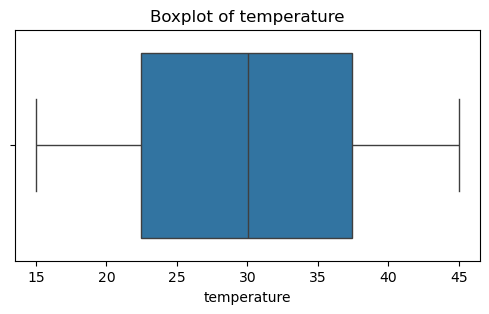

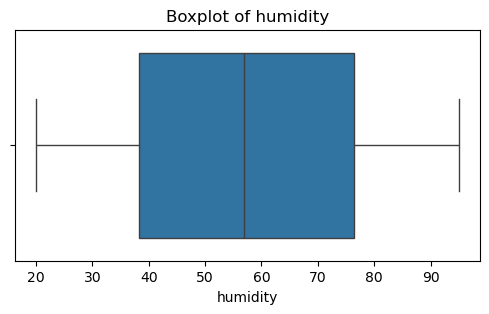

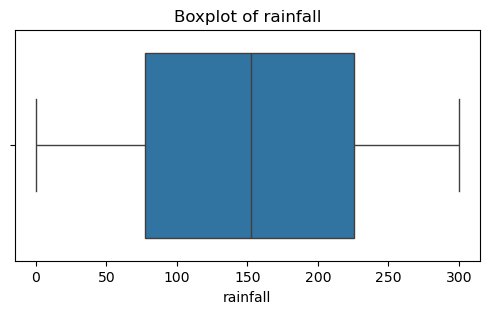

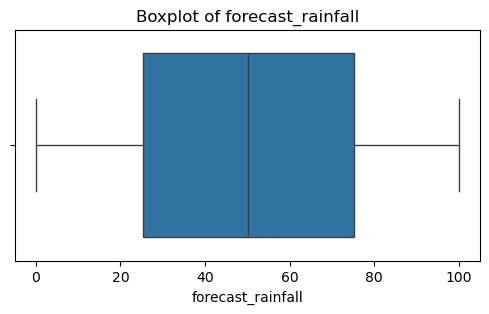

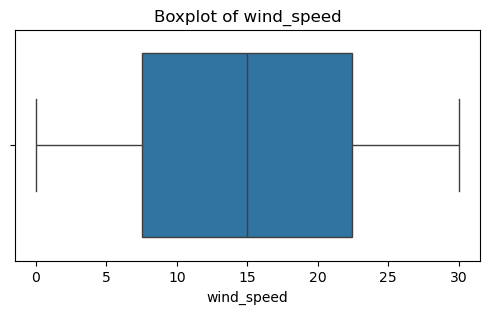

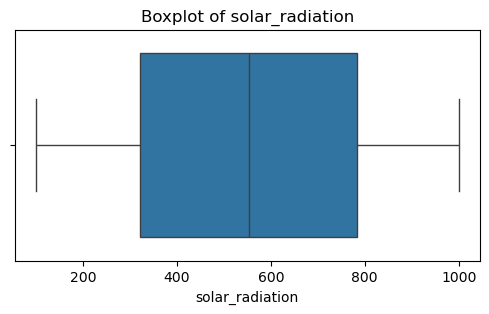

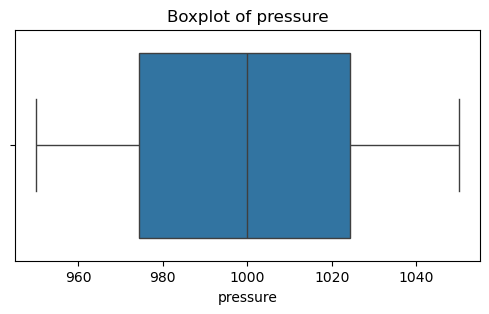

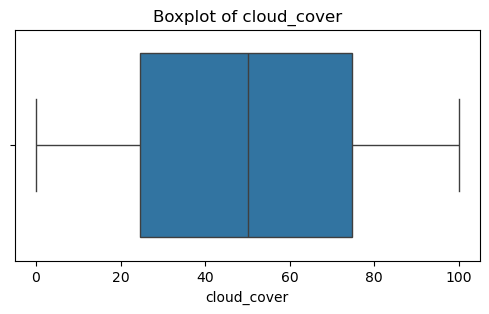

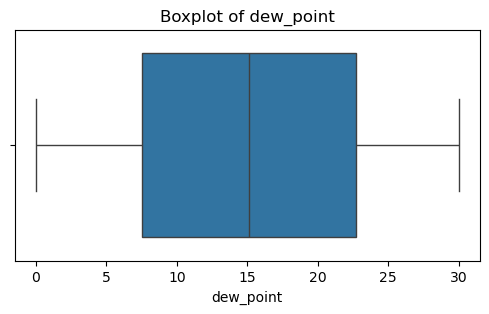

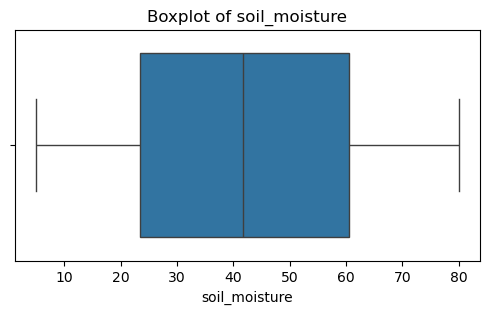

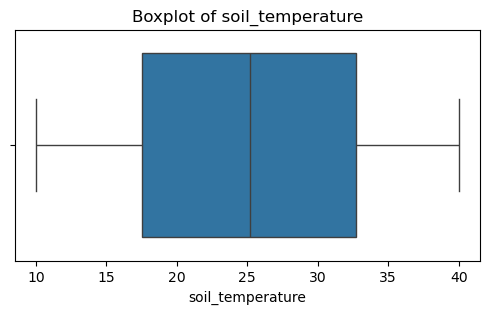

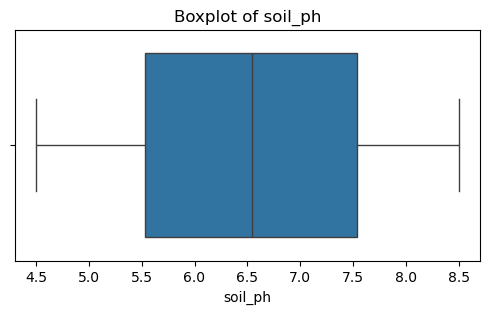

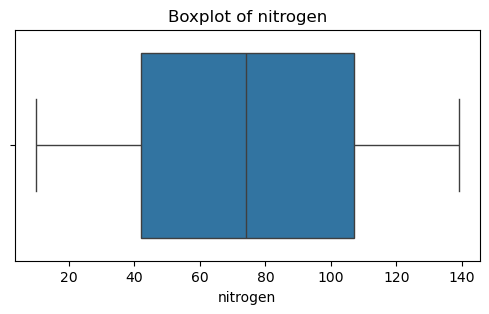

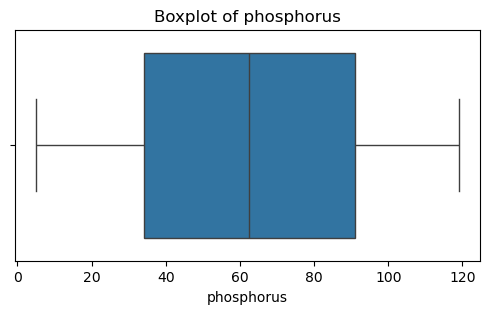

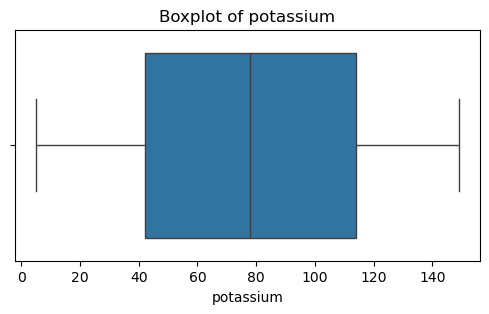

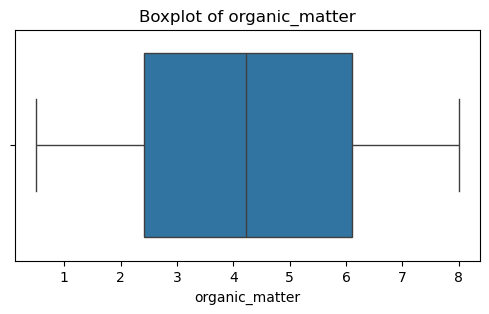

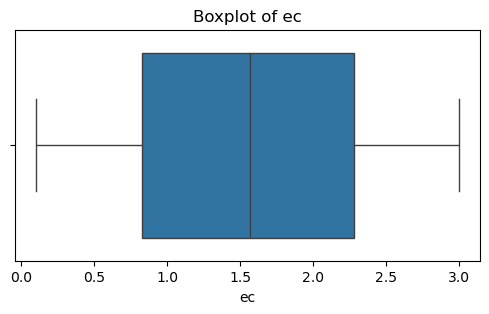

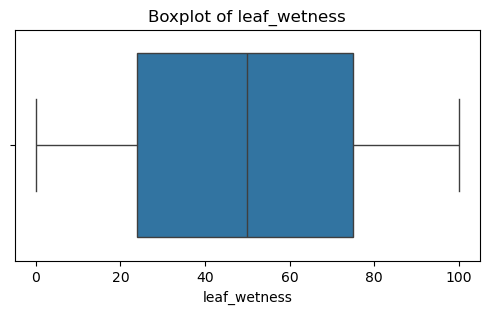

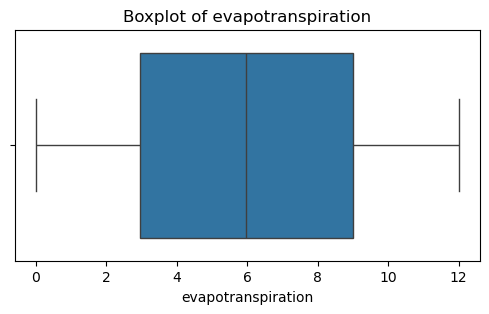

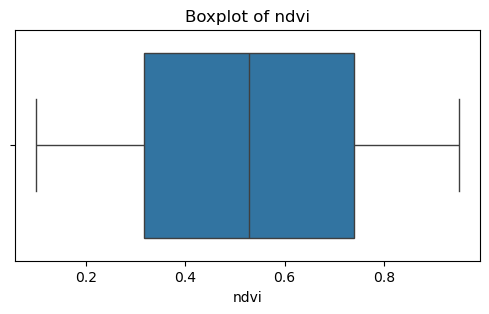

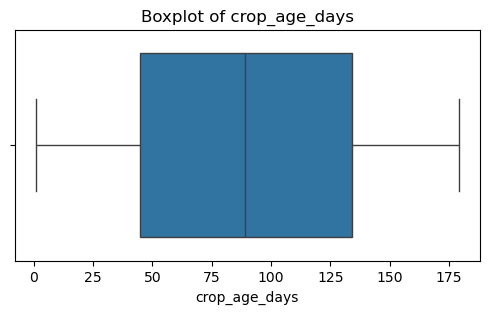

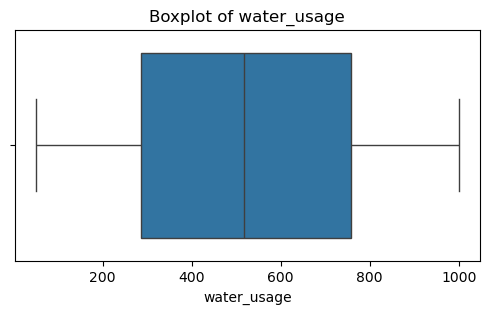

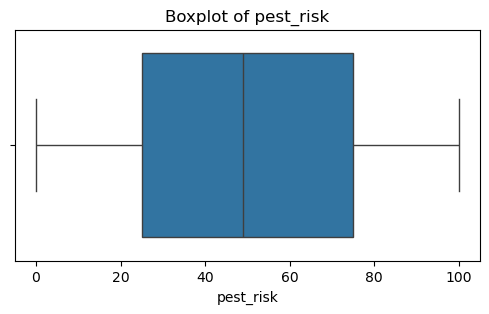

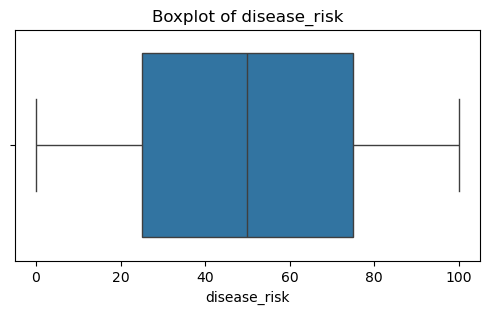

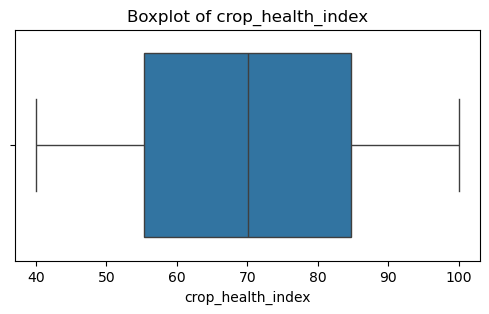

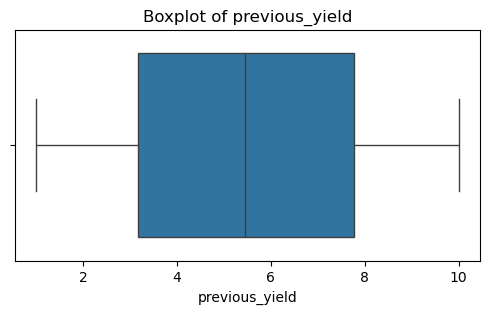

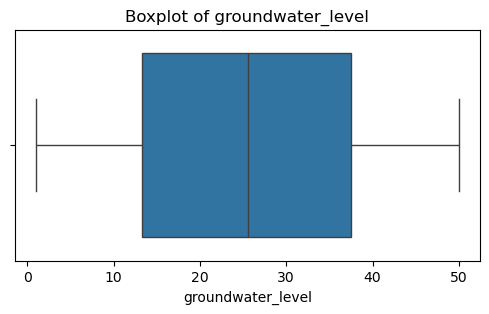

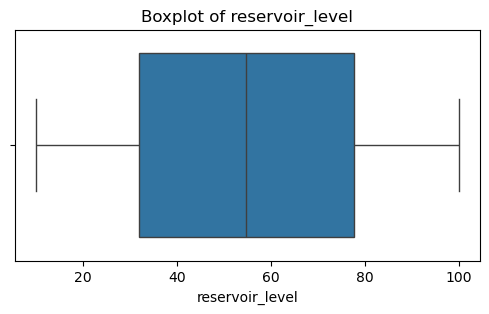

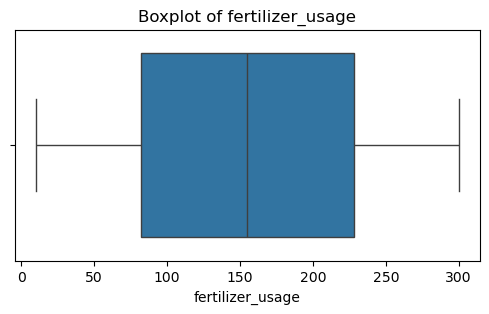

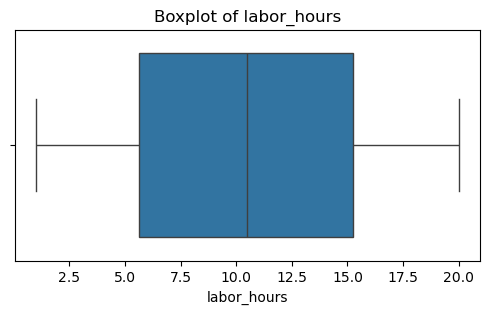

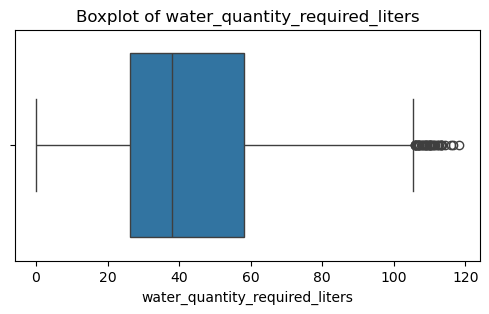

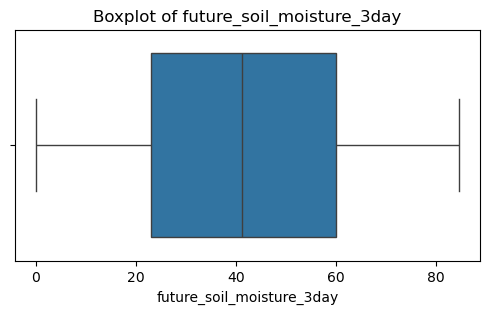

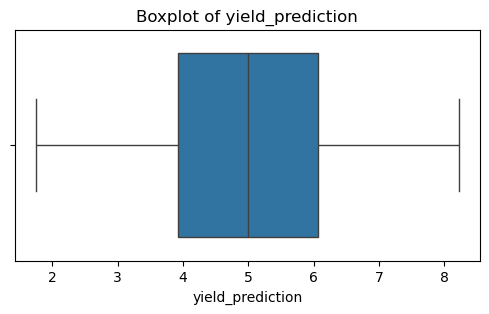

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in num_col_list:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()



In [24]:
print(df.dtypes["growth_stage"])

object


# **Encoding**

In [25]:
results

,column,Unique values count,Encoding Method
0,crop_type,5,One-Hot Encoding
1,region,4,One-Hot Encoding
2,irrigation_required,2,Label Encoding
3,irrigation_type,3,One-Hot Encoding
4,growth_stage,4,Label Encoding
5,crop_water_stress_level,3,Label Encoding
6,soil_type,4,One-Hot Encoding


# One-Hot Encoding

In [26]:
df = pd.get_dummies(
    df,
    columns=['crop_type', 'region', 'soil_type', 'irrigation_type'],
    drop_first=True,
    
)

# Label Encoding

In [27]:
from sklearn.preprocessing import LabelEncoder

lr_irrigation_required = LabelEncoder()

df['irrigation_required'] = lr_irrigation_required.fit_transform(df['irrigation_required'])

lr_growth_stage = LabelEncoder()

df['growth_stage'] = lr_growth_stage.fit_transform(df['growth_stage'])

lr_crop_water_stress_level = LabelEncoder()
df['crop_water_stress_level'] = lr_crop_water_stress_level.fit_transform(df['crop_water_stress_level'])


In [28]:
print(lr_growth_stage.classes_)

['Flowering' 'Maturity' 'Seedling' 'Vegetative']


In [29]:
print(lr_crop_water_stress_level.classes_)

['High' 'Low' 'Medium']


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 48 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   growth_stage                    10000 non-null  int64  
 1   temperature                     10000 non-null  float64
 2   humidity                        10000 non-null  float64
 3   rainfall                        10000 non-null  float64
 4   forecast_rainfall               10000 non-null  float64
 5   wind_speed                      10000 non-null  float64
 6   solar_radiation                 10000 non-null  float64
 7   pressure                        10000 non-null  float64
 8   cloud_cover                     10000 non-null  float64
 9   dew_point                       10000 non-null  float64
 10  soil_moisture                   10000 non-null  float64
 11  soil_temperature                10000 non-null  float64
 12  soil_ph                         1

In [31]:
#convert boolean columns to integers
bool_columns = df.select_dtypes(include=['bool']).columns
df[bool_columns] = df[bool_columns].astype(int)

In [32]:
df

,growth_stage,temperature,humidity,rainfall,forecast_rainfall,wind_speed,solar_radiation,pressure,cloud_cover,dew_point,...,crop_type_Sugarcane,crop_type_Wheat,region_North,region_South,region_West,soil_type_Loamy,soil_type_Sandy,soil_type_Silty,irrigation_type_Flood,irrigation_type_Sprinkler
0,3,30.11,56.83,244.37,25.49,16.22,494.42,956.28,18.19,7.38,...,0,0,0,0,0,1,0,0,0,0
1,2,16.98,33.83,77.67,7.17,14.98,958.41,971.66,49.19,28.17,...,0,0,0,0,1,0,0,1,0,1
2,2,41.51,56.24,241.26,38.82,4.25,944.36,1022.92,2.19,16.81,...,1,0,1,0,0,0,0,0,0,1
3,3,37.59,34.14,124.00,73.21,3.65,712.11,976.40,35.25,23.10,...,0,0,0,0,0,0,0,0,0,0
4,2,26.36,72.79,79.94,21.39,3.91,995.69,970.73,5.53,22.34,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,3,26.20,59.10,56.35,79.90,4.79,889.47,1033.28,60.84,24.43,...,1,0,0,0,1,0,1,0,1,0
9996,0,43.02,72.26,122.98,15.10,25.83,835.13,1019.34,55.47,17.20,...,1,0,0,0,0,0,0,1,0,0
9997,1,43.68,37.26,202.85,46.27,12.22,623.76,998.58,51.32,20.68,...,0,1,0,1,0,0,0,0,1,0
9998,3,32.46,76.37,89.30,30.46,18.61,698.84,962.22,24.64,1.85,...,0,1,0,1,0,0,1,0,0,1


# Save clean data in new csv file

In [ ]:
df.to_csv('../data/processed/smart_irrigation_cleaned.csv', index=False)

In [ ]:
import os

os.listdir('../data/processed')

['smart_irrigation_cleaned.csv']

In [36]:
import joblib

joblib.dump(lr_growth_stage,
            "../models/growth_stage_encoder.pkl")

['../models/growth_stage_encoder.pkl']

In [35]:
import joblib

joblib.dump(lr_crop_water_stress_level,
            "../models/crop_water_stress_level.pkl")

['../models/crop_water_stress_level.pkl']

In [38]:
# joblib is already imported earlier in the notebook (cells 39/40),
# so we just load the correct filename that was saved previously.
encoder = joblib.load("../models/crop_water_stress_level.pkl")

print(encoder.classes_)

['High' 'Low' 'Medium']


In [39]:
for item in encoder.classes_:
    print(item, "->", encoder.transform([item])[0])

High -> 0
Low -> 1
Medium -> 2
